# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [ ]:
# run this first if you dont have them installed in your env
%pip install pandas numpy matplotlib scipy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("data/cars.csv")
print(df.shape)
df.head()

---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [ ]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()

# Check for duplicate rows
print("Number of duplicates:", df.duplicated().sum())

In [ ]:
# Check for common values
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))

In [ ]:
# Check for extreme values
print(df.describe())

In [ ]:
# Check categorical values
categorical_cols = df.select_dtypes(exclude="number").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

In [ ]:
# Investigate suspicious MSRP = $2,000
print("Rows with MSRP = $2,000:", (df["MSRP"] == 2000).sum())

print("\nBy year:")
print(df[df["MSRP"] == 2000]["Year"].value_counts().sort_index())

print("\nBy make:")
print(df[df["MSRP"] == 2000]["Make"].value_counts().head(20))

print("\nSample of rows:")
print(
    df[df["MSRP"] == 2000][
        ["Make", "Model", "Year", "Engine HP",
         "Engine Cylinders", "Transmission Type", "MSRP"]
    ].head(30).to_string(index=False)
)


In [ ]:
# Investigate UNKNOWN transmission
print(
    df[df["Transmission Type"] == "UNKNOWN"][
        ["Make", "Model", "Year", "Transmission Type",
         "Engine Fuel Type", "Engine HP", "Engine Cylinders", "MSRP"]
    ].to_string(index=False)
)

In [ ]:
# Investigate Number of Doors = 3
print(
    df[df["Number of Doors"] == 3][
        ["Make", "Model", "Year", "Vehicle Style", "Number of Doors"]
    ].head(30).to_string(index=False)
)

print("\nVehicle styles:")
print(df[df["Number of Doors"] == 3]["Vehicle Style"].value_counts())

print(
    df[df["Number of Doors"] == 3][
        ["Make", "Model", "Year", "Vehicle Style", "Number of Doors"]
    ].drop_duplicates().to_string(index=False)
)

In [ ]:
# Investigate MPG by fuel type
print(
    df.groupby("Engine Fuel Type")[["highway MPG", "city mpg"]].agg(
        ["count", "min", "median", "max"]
    )
)

print("\nHighest highway MPG:")
print(
    df.nlargest(20, "highway MPG")[
        ["Make", "Model", "Year", "Engine Fuel Type",
         "highway MPG", "city mpg", "MSRP"]
    ].to_string(index=False)
)

print("\nHighest city MPG:")
print(
    df.nlargest(20, "city mpg")[
        ["Make", "Model", "Year", "Engine Fuel Type",
         "highway MPG", "city mpg", "MSRP"]
    ].to_string(index=False)
)

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | 720 duplicate rows in the dataset | df.duplicated().sum() | 720 | Dropped the duplicates | Because the dataset is supposed to represent car trims, not individual copies of cars. |
| 2 | MSRP of $2,000 appears suspiciously often | df["MSRP"].value_counts() and inspection of the $2,000 rows | 1,036 | Set MSRP values of $2,000 to NaN | The exact same low MSRP appears across 1,036 vehicles from 1990–2000 and many different makes/models, suggesting it is a placeholder rather than a true MSRP. |
| 3 | 19 rows have UNKNOWN as the transmission type | df["Transmission Type"].value_counts() | 19 | Replaced UNKNOWN with NaN | UNKNOWN is not a known transmission type, and we cannot guess the transmission type. |
| 4 | Number of Doors = 3 seemed unusual | Checked the vehicle styles and models associated with 3-door vehicles | 395 | Leave unchanged | It is mostly vans, minivans, pickups, and hatchbacks with 3-doors rather than random vehicles, so they likely represent accurate configurations. |
| 5 | An extremely high highway MPG value of 354 for the Audi A6 | Compared MPG ranges across fuel types and inspected the highest MPG values | 1 | Set highway MPG to NaN | Electric vehicles have higher MPG values, but 354 is an extreme outlier that's inconsistent with the Audi A6's city MPG of 24. |

In [51]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()

clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")


# 1. Drop duplicate rows
clean = clean.drop_duplicates()


# 2. Replace suspicious MSRP values of $2,000 with NaN
clean.loc[clean["msrp"] == 2000, "msrp"] = np.nan


# 3. Replace UNKNOWN transmission values with NaN
clean["transmission_type"] = clean["transmission_type"].replace("UNKNOWN", np.nan)


# 5. Replace the suspicious Audi A6 highway MPG value of 354 with NaN
mask = (
    (clean["make"] == "Audi") &
    (clean["model"] == "A6") &
    (clean["year"] == 2017) &
    (clean["highway_mpg"] == 354)
)

clean.loc[mask, "highway_mpg"] = np.nan

In [52]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 15)
engine_fuel_type       3
engine_hp             69
engine_cylinders      30
transmission_type     12
number_of_doors        6
highway_mpg            1
msrp                 747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean MSRP: 44788.66689001627
Median MSRP: 31870.0


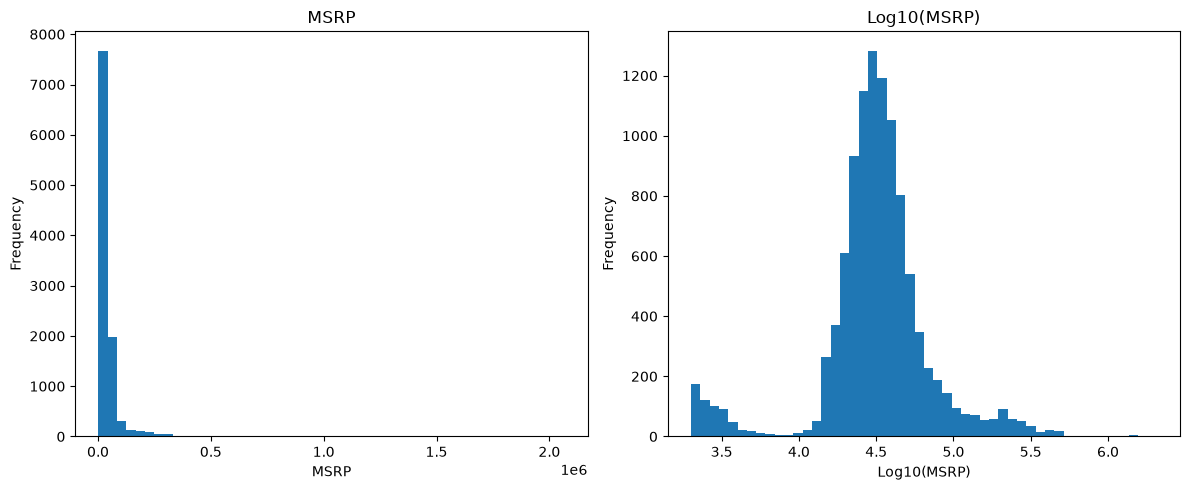

Percent of cars above the mean: 22.815794175451135


In [53]:
# a) Mean and median
mean_msrp = clean["msrp"].mean()
median_msrp = clean["msrp"].median()

print("Mean MSRP:", mean_msrp)
print("Median MSRP:", median_msrp)

# b) Histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(clean["msrp"].dropna(), bins=50)
axes[0].set_title("MSRP")
axes[0].set_xlabel("MSRP")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log10(clean["msrp"].dropna()), bins=50)
axes[1].set_title("Log10(MSRP)")
axes[1].set_xlabel("Log10(MSRP)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# c) Percent of cars costing more than the mean
percent_above_mean = (clean["msrp"] > mean_msrp).mean() * 100

print("Percent of cars above the mean:", percent_above_mean)

**Answer:**

a) Compute the mean and median MSRP. Which is bigger, and why? The mean MSRP is larger than the median MSRP, being roughly $44,789, while the median MSRP is only $31,870. The reason that the mean MSRP is larger than the median MSRP because the distribution of MSRP is skewed to the right. I know this because the MSRP histogram has a "tail", meaning there are outliers that lie above the median and mean, pulling the mean upward. The mean is affected more by outliers than the median is, since it is an average rather than based on the middle value in a dataset. 

b) The MSRP histogram is unimodal and is skewed to the right, having a right tail. The log 10 histogram is roughly symmetrical and is also unimodal. 

c) The percent of cars that costs more than $44,789 is around 22.8% of cars. This suggests that the distribution of MSRP is not symmetrical, because in a symmetrical distribution, roughly half of the cars would cost more than the mean, while the other half would cost less. Here, however, it seems that most cars cost far less than the mean MSRP, but some higher values, that are outliers, have pulled the mean up.

d) If the goal is to be truthful, then the median should be on the homepage, since it is less affected by the outliers, and is a more accurate measure of central tendency in this instance. 

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [54]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only

# 2017 cars only
cars_2017 = clean[clean["year"] == 2017]

# Mean and standard deviation of highway MPG by vehicle size
mpg_by_size = cars_2017.groupby("vehicle_size")["highway_mpg"].agg(["mean", "std"])

print(mpg_by_size)

# b) z = (value - class mean) / class std

# Get the class statistics
stats = cars_2017.groupby("vehicle_size")["highway_mpg"].agg(["mean", "std"])

# Honda Civic: Compact
civic_mean = stats.loc["Compact", "mean"]
civic_std = stats.loc["Compact", "std"]
civic_z = (42 - civic_mean) / civic_std

# Volvo S90: Large
volvo_mean = stats.loc["Large", "mean"]
volvo_std = stats.loc["Large", "std"]
volvo_z = (34 - volvo_mean) / volvo_std

print("Honda Civic z-score:", civic_z)
print("Volvo S90 z-score:", volvo_z)

                   mean        std
vehicle_size                      
Compact       31.994197  10.784983
Large         22.991453   3.491184
Midsize       29.410658   5.452292
Honda Civic z-score: 0.927753222478232
Volvo S90 z-score: 3.1532419821950963


**Answer:**

c) The vehicle that is more fuel-efficient for its class is the Volvo S90, because it has a much higher z-score than the Honda Civic does. The Volvo S90 is 3.15 standard deviations above the mean MPG for its class, while the Honda Civic is only 0.93 standard deviations above the mean MPG for its class.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

2017 median MSRP: 36737.5
95% bootstrap interval: 35940.0 37682.5625


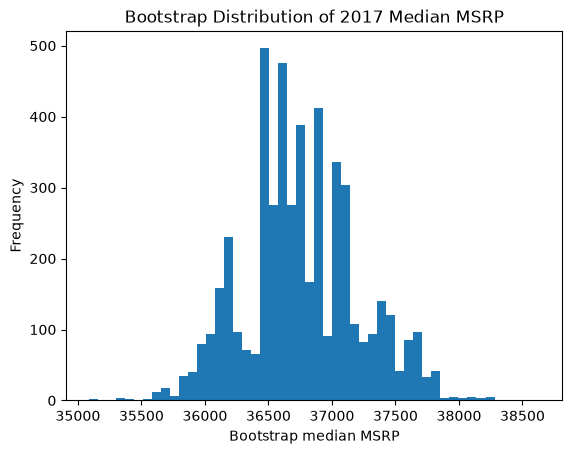


Hyundai median MSRP: 26850.0
Hyundai 95% bootstrap interval: 24125.0 30987.5


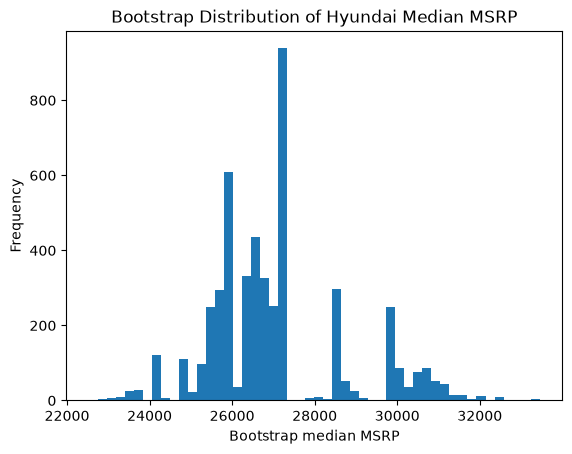

In [60]:
# Set up random number generator
rng = np.random.default_rng(42)

# Bootstrap function
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    
    medians = []

    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        medians.append(np.median(sample))

    return np.array(medians)

# 2017 cars
cars_2017 = clean[clean["year"] == 2017]

# a) Median MSRP of 2017 cars
prices_2017 = cars_2017["msrp"].dropna().values
median_2017 = np.median(prices_2017)

print("2017 median MSRP:", median_2017)

# b) Bootstrap the 2017 median 5,000 times
boot_medians = bootstrap_median(prices_2017)

# 95% bootstrap interval
lower = np.percentile(boot_medians, 2.5)
upper = np.percentile(boot_medians, 97.5)

print("95% bootstrap interval:", lower, upper)

# Plot the 5,000 bootstrap medians
plt.hist(boot_medians, bins=50)
plt.xlabel("Bootstrap median MSRP")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of 2017 Median MSRP")
plt.show()

# c) Choose Hyundai, which has fewer than 50 cars in 2017
chosen_make = "Hyundai"

one_make = cars_2017[cars_2017["make"] == chosen_make]
make_prices = one_make["msrp"].dropna().values

# Bootstrap the Hyundai median
make_boot_medians = bootstrap_median(make_prices)

# 95% bootstrap interval
make_lower = np.percentile(make_boot_medians, 2.5)
make_upper = np.percentile(make_boot_medians, 97.5)

print(f"\n{chosen_make} median MSRP:", np.median(make_prices))
print(f"{chosen_make} 95% bootstrap interval:", make_lower, make_upper)


# Plot the bootstrap medians for Hyundai
plt.hist(make_boot_medians, bins=50)
plt.xlabel("Bootstrap median MSRP")
plt.ylabel("Frequency")
plt.title(f"Bootstrap Distribution of {chosen_make} Median MSRP")
plt.show()

**Answer:**

a) The median MSRP of 2017 cars is $36,737.50.

b) The 95% confidence interval for the 5,000 resampled/bootstrapped 2017 prices is between $35,940 and $37,682.56.

c) The 95% bootstrap interval for Hyundai is wider, because it is between $24,125 and $30,987.50, which is a range of 
$6,862.50, while the range of the 2017 cars is only $1742.56. The reason for this is because the sample size is smaller. The amount of Hyundai cars is less than 50, while the amount of 2017 cars is a lot more. A smaller sample size leaves more room for sampling error and innaccuracy. For example, if your sample only contained 2 data points, you only get 2 chances to select from the population, so it is not as surprising if you get 2 outliers or unusually high values. However, if you took hundreds of data points from the population, it would be unlikely that you got an extreme value most of the time. 

d) We are 95% certain that the true median MSRP of 2017 cars is between $35,940 and $37,682.56.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

n: 517
Mean: 31.994197292069632
SD: 10.78498297338453


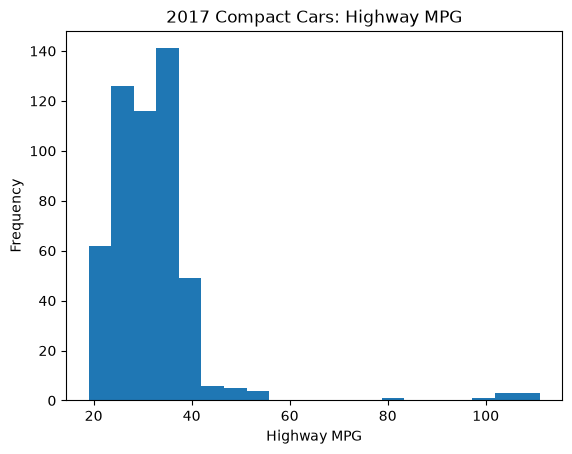


T-statistic: 4.204302247520252
p-value: 1.5436064323576802e-05

Rows per make + model:
make        model   
Toyota      Tacoma      27
Chevrolet   Corvette    24
Nissan      Frontier    22
            370Z        17
Porsche     911         14
                        ..
Ford        Focus ST     1
            Focus RS     1
FIAT        500e         1
Lexus       CT 200h      1
Mitsubishi  i-MiEV       1
Length: 90, dtype: int64

Number of models: 90
Mean: 35.62398018043443
SD: 17.23130923408485
T-statistic: 3.0963265723253786
p-value: 0.0013101641852761596


In [62]:
import scipy.stats as scipy_stats

# b) Sample: 2017 compact cars (MPG you trust); n, mean, histogram

compact_rows = clean[
    (clean["year"] == 2017) &
    (clean["vehicle_size"] == "Compact")
]

compact_2017 = compact_rows["highway_mpg"].dropna()

print("n:", len(compact_2017))
print("Mean:", compact_2017.mean())
print("SD:", compact_2017.std())

plt.hist(compact_2017, bins=20)
plt.xlabel("Highway MPG")
plt.ylabel("Frequency")
plt.title("2017 Compact Cars: Highway MPG")
plt.show()


# c) One-sample t-test against 30 MPG

result = scipy_stats.ttest_1samp(
    compact_2017,
    popmean=30,
    alternative="greater"
)

print("\nT-statistic:", result.statistic)
print("p-value:", result.pvalue)


# d) Rows per make + model

model_counts = (
    compact_rows
    .groupby(["make", "model"])
    .size()
    .sort_values(ascending=False)
)

print("\nRows per make + model:")
print(model_counts)


# Average to one row per make + model

compact_by_model = (
    compact_rows
    .groupby(["make", "model"])["highway_mpg"]
    .mean()
    .dropna()
)

print("\nNumber of models:", len(compact_by_model))
print("Mean:", compact_by_model.mean())
print("SD:", compact_by_model.std())


# Rerun t-test with one row per make + model

result_model = scipy_stats.ttest_1samp(
    compact_by_model,
    popmean=30,
    alternative="greater"
)

print("T-statistic:", result_model.statistic)
print("p-value:", result_model.pvalue)

**Answer:**

a) H₀: μ = 30 MPG
Hₐ: μ > 30 MPG

This is a one-sided t-test because we are trying to reject our null hypothesis that 2017 compacts do not average over 30 MPG. Since we only want to know what is above 30 MPG, we are only looking at the right of 30, at the right tail. 

b) There are 517 cars in the sample (n). The distribution of cars is somewhat symmetrical, although it is bimodal. It is also slightly skewed to the right, with some outliers around 80 and 100 MPG. A t-test is reasonable here, because although the distribution is not quite normal, it is not severely non-normal, and we have a large enough sample of data. 

c) We reject the null hypothesis. There is statistically significant evidence that 2017 compact cars average more than 30 MPG on the highway.

d) The p-value got larger in this version of the t-test (0.00131 vs 0.0000154), although it is still statistically significant. I trust this version of the t-test more, because the other test may have given some models more weight than others due to them appearing many times, which also violations one of the assumptions for running a t-test. 



### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [63]:
# a) Compare median MSRP by transmission type
transmission_medians = (
    clean[clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"])]
    .groupby("transmission_type")["msrp"]
    .median()
)

print("Median MSRP:")
print(transmission_medians)


# b) Compare year by transmission type
year_by_transmission = (
    clean[clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"])]
    .groupby("transmission_type")["year"]
    .agg(["count", "median", "min", "max"])
)

print("\nYear by transmission:")
print(year_by_transmission)


# c) 2015–2017: compare median MSRP overall and within each vehicle size
recent = clean[
    (clean["year"].between(2015, 2017)) &
    (clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"]))
]

print("\n2015–2017 median MSRP:")
print(recent.groupby("transmission_type")["msrp"].median())

print("\n2015–2017 median MSRP by vehicle size:")
print(
    recent.groupby(["vehicle_size", "transmission_type"])["msrp"]
    .median()
)


# Mann–Whitney U test for 2015–2017 compact cars
compact = recent[recent["vehicle_size"] == "Compact"]

auto = compact.loc[
    compact["transmission_type"] == "AUTOMATIC", "msrp"
].dropna()

manual = compact.loc[
    compact["transmission_type"] == "MANUAL", "msrp"
].dropna()

result = scipy_stats.mannwhitneyu(auto, manual)

print("\n2015–2017 compact cars:")
print("Automatic median:", auto.median())
print("Manual median:", manual.median())
print("p-value:", result.pvalue)

Median MSRP:
transmission_type
AUTOMATIC    33620.0
MANUAL       21875.0
Name: msrp, dtype: float64

Year by transmission:
                   count  median   min   max
transmission_type                           
AUTOMATIC           7928  2015.0  1990  2017
MANUAL              2633  2008.0  1990  2017

2015–2017 median MSRP:
transmission_type
AUTOMATIC    37065.0
MANUAL       26905.0
Name: msrp, dtype: float64

2015–2017 median MSRP by vehicle size:
vehicle_size  transmission_type
Compact       AUTOMATIC            25995.0
              MANUAL               25860.0
Large         AUTOMATIC            44400.0
              MANUAL               38395.0
Midsize       AUTOMATIC            37980.0
              MANUAL               26920.0
Name: msrp, dtype: float64

2015–2017 compact cars:
Automatic median: 25995.0
Manual median: 25860.0
p-value: 0.20483161191397048


**Answer:**

a) The median MSRP of automatic cars is somewhat higher, at $33,620, while the median MSRP of manual cars is only $21,875. 

b) After comparing the year of manual vs automatic cars, I noticed that the median year for manual cars is 7 years lower than the median year for automatic cars, being 2008 versus 2015. Since older cars may also tend to have a lower MSRP due to their age rather than due to whether they are automatic or manual, the car's year may be a confounding variable. 

c) After restricting the comparison to 2015–2017 cars and comparing within vehicle size, the difference becomes much smaller. For compact cars, the median prices differ by only $135, and the Mann–Whitney U test is not statistically significant (p = 0.205).

d) You shouldn't push manual cars to budget shoppers, because after accounting for year and vehicle size, the price difference is much smaller and is not statistically significant for 2015–2017 compact cars.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [64]:
# Get 2-door and 4-door cars with valid highway MPG
doors = clean[
    clean["number_of_doors"].isin([2, 4]) &
    clean["highway_mpg"].notna()
]

two_door = doors.loc[doors["number_of_doors"] == 2, "highway_mpg"]
four_door = doors.loc[doors["number_of_doors"] == 4, "highway_mpg"]


# a) Welch t-test
result = scipy_stats.ttest_ind(
    four_door,
    two_door,
    equal_var=False
)

print("4-door mean MPG:", four_door.mean())
print("2-door mean MPG:", two_door.mean())
print("Difference in means:", four_door.mean() - two_door.mean())
print("p-value:", result.pvalue)


# b) Yearly gas cost
miles = 12000
price_per_gallon = 3.50

four_door_cost = miles * price_per_gallon / four_door.mean()
two_door_cost = miles * price_per_gallon / two_door.mean()

print("\n4-door yearly gas cost:", four_door_cost)
print("2-door yearly gas cost:", two_door_cost)
print("Yearly savings:", two_door_cost - four_door_cost)


# c) Simulation: 30 cars per group, repeated 1,000 times
rng = np.random.default_rng(42)

n_sims = 1000
hits = 0

for _ in range(n_sims):
    four_sample = rng.choice(four_door, 30, replace=False)
    two_sample = rng.choice(two_door, 30, replace=False)

    test = scipy_stats.ttest_ind(
        four_sample,
        two_sample,
        equal_var=False
    )

    if test.pvalue < 0.05:
        hits += 1

print("\nFraction significant:", hits / n_sims)

4-door mean MPG: 27.330986800754243
2-door mean MPG: 25.339360222531294
Difference in means: 1.9916265782229488
p-value: 1.2869410530634689e-37

4-door yearly gas cost: 1536.7172911166508
2-door yearly gas cost: 1657.500411658159
Yearly savings: 120.7831205415082

Fraction significant: 0.137


**Answer:** 

a) The mean difference is 1.99 MPG, with p < 0.001 (your exact p-value is 1.29 x 10^-37. So the difference is statistically significant.

b) The average 4-door driver saves about $120.78 per year in gas compared with the average 2-door driver.

c) 13.7% of the simulated tests were significant. So with only 30 cars per group, the test detects the difference less often.

d) I would not put “4-door cars are significantly more fuel-efficient” in an ad because “significant” makes the difference sound more practically important than it necessarily is. The actual difference is only about 2 MPG, although that translates to roughly $121/year in average fuel savings.

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** Manual cars appear to cost less overall, with a median MSRP of $21,875 compared with $33,620 for automatic cars, but manual cars are also generally older. When we limited the comparison to 2015–2017 cars and compared cars within the same vehicle size, the difference was much smaller; for compact cars, the median prices were $25,860 for manual cars and $25,995 for automatic cars. Another important pricing finding is that MSRP is strongly right-skewed, meaning a small number of very expensive cars pull the average upward, so the median is a better measure of a typical car's price. One limitation is that this dataset contains different numbers of trims for different models, so cars with more trims can have more influence on the results.

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2